In [ ]:
# !pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-geometric

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124


In [2]:
# Install correct environment

!pip install torch==2.0.0+cu118 torchvision==0.15.1+cu118 torchaudio==2.0.1+cu118 -f https://download.pytorch.org/whl/torch_stable.html
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install numpy==1.24.4
!pip install optuna


Looking in links: https://download.pytorch.org/whl/torch_stable.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html
  Using cached torch_geometric-2.6.1-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.6.1-py3-none-any.whl (1.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 111.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
pymc 5.22.0 requires numpy>=1.25.0, but you have numpy 1.24.4 whic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 24.2 MB/s eta 0:00:00



Import all necessary libraries.


Full Step: Import Libraries, Set Seed

In [1]:
# Import libraries needed for graph construction and model building

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, HeteroConv
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import optuna
import random
import time
import math
import matplotlib.pyplot as plt
import re
import collections
from collections import Counter


In [2]:
# Define a function to set random seed across all libraries

def jenny_setter(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set the seed value
jenny = 8675309
jenny_setter(seed=jenny)


Load All the Necessary Files



In [3]:
# Load the enriched county feature matrix
county_feat = pd.read_csv("enriched_county_feature_matrix.csv", low_memory=False)

# Load the county node id map
county_id_map = pd.read_csv("DATA002_county_node_id_map_v1.csv", low_memory=False)

# Load the superfund feature matrix
superfund_feat = pd.read_csv("DATA001_superfund_feature_matrix_v1.csv", low_memory=False)

# Load the superfund node id map
superfund_id_map = pd.read_csv("DATA001_superfund_node_id_map_v1.csv", low_memory=False)

# Enforce correct ID formatting
superfund_id_map['site_id'] = superfund_id_map['site_id'].astype(str).str.zfill(7)
superfund_id_map['fips'] = superfund_id_map['fips'].astype(str).str.zfill(5)
county_id_map['fips'] = county_id_map['fips'].astype(str).str.zfill(5)

# Cast feature matrices to float32
superfund_feat = superfund_feat.astype(np.float32)
county_feat = county_feat.astype(np.float32)

# Show basic info
print("Files loaded and formatted:")
print("Enriched County feature shape:", county_feat.shape)
print("County ID map shape:", county_id_map.shape)
print("Superfund feature shape:", superfund_feat.shape)
print("Superfund ID map shape:", superfund_id_map.shape)


Files loaded and formatted:
Enriched County feature shape: (2930, 19)
County ID map shape: (2930, 2)
Superfund feature shape: (1606, 739)
Superfund ID map shape: (1606, 3)


In [4]:
# Check that FIPS codes in County ID map are correctly formatted
valid_fips_county = county_id_map['fips'].apply(lambda x: isinstance(x, str) and len(x) == 5 and x.isdigit())
print(f"Valid County FIPS codes: {valid_fips_county.sum()} / {len(county_id_map)}")

# Check that FIPS codes in Superfund ID map are correctly formatted
valid_fips_superfund = superfund_id_map['fips'].apply(lambda x: isinstance(x, str) and len(x) == 5 and x.isdigit())
print(f"Valid Superfund FIPS codes: {valid_fips_superfund.sum()} / {len(superfund_id_map)}")

# Check how many Superfund FIPS codes overlap with County FIPS codes
superfund_fips_set = set(superfund_id_map['fips'])
county_fips_set = set(county_id_map['fips'])

overlap_count = len(superfund_fips_set & county_fips_set)
total_superfund_fips = len(superfund_fips_set)

print(f"Superfund FIPS matched to Counties: {overlap_count} / {total_superfund_fips}")


Valid County FIPS codes: 2930 / 2930
Valid Superfund FIPS codes: 1606 / 1606
Superfund FIPS matched to Counties: 677 / 738


we have 677 superfund sites that match with county FIPS , which is sufficient to construct meaningful graph edges.

Edge Construction and HeteroData Setup

In [5]:
# Step: Merge superfund → county edge information using 'fips' codes
edge_df = superfund_id_map.merge(
    county_id_map,
    on='fips',
    suffixes=('_superfund', '_county')
).copy(deep=True)

# Step: Convert edge pairs (superfund → county) into an edge index tensor
edge_array = np.stack([
    edge_df['row_index_superfund'].values,
    edge_df['row_index_county'].values
], axis=0)
edge_index = torch.from_numpy(edge_array).long()

# Step: Convert feature matrices into PyTorch tensors
superfund_x = torch.tensor(superfund_feat.values, dtype=torch.float32)
county_feats = county_feat.drop(columns=['cancer_rate']).copy()
county_x = torch.tensor(county_feats.values, dtype=torch.float32)

# Step: Initialize the HeteroData object and assign node features
data = HeteroData()
data['superfund'].x = superfund_x
data['county'].x = county_x

# Step: Assign edges in both directions (superfund → county, and reverse)
data['superfund', 'located_in', 'county'].edge_index = edge_index
data['county', 'has_site', 'superfund'].edge_index = edge_index.flip(0)

# Step: Assign cancer rate labels to counties
data['county'].y = torch.tensor(
    county_feat['cancer_rate'].values,
    dtype=torch.float32
)

# Step: Verify data integrity
print('__ Data Object __')
print(data)
print('-------------------------------')
print('Superfund node shape:', data['superfund'].x.shape)
print('County node shape:', data['county'].x.shape)
print('Edge shape (superfund → county):', data['superfund', 'located_in', 'county'].edge_index.shape)
print('-------------------------------')

# Step: Double-check index alignment
assert np.array_equal(county_id_map['row_index'].values, county_feat.index.values), \
    "ERROR: Misaligned county_id_map and county_feat."

assert np.array_equal(superfund_id_map['row_index'].values, superfund_feat.index.values), \
    "ERROR: Misaligned superfund_id_map and superfund_feat."


__ Data Object __
HeteroData(
  superfund={ x=[1606, 739] },
  county={
    x=[2930, 18],
    y=[2930],
  },
  (superfund, located_in, county)={ edge_index=[2, 1505] },
  (county, has_site, superfund)={ edge_index=[2, 1505] }
)
-------------------------------
Superfund node shape: torch.Size([1606, 739])
County node shape: torch.Size([2930, 18])
Edge shape (superfund → county): torch.Size([2, 1505])
-------------------------------


We built a heterogeneous graph where each node is either a superfund site or a county. We used real-world data to connect 1,606 superfund sites to 2,930 counties through 1,505 spatial links. Each county has 18 features and one cancer rate label, while each superfund site has 739 features. The model will use this graph structure to learn how county-level cancer rates relate to surrounding superfund features.

In [6]:
print(county_feat.columns)



Index(['cancer_rate', 'avg_annual_count', 'five_year_trend', 'has_cancer_data',
       'rural_rural', 'rural_urban', 'trend_', 'trend_falling', 'trend_rising',
       'trend_stable', 'High_Medium', 'High_Old', 'High_Recent', 'Low_Medium',
       'Low_Old', 'Low_Recent', 'Medium_Medium', 'Medium_Old',
       'Medium_Recent'],
      dtype='object')


Mean:   454.41
Median: 459.90
Std:    58.15


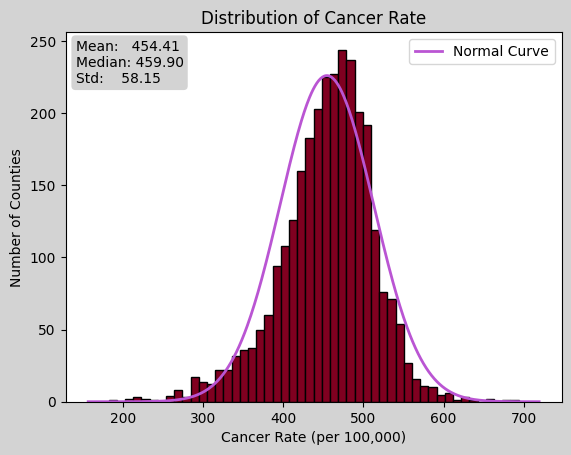


Scaling decision: Do not scale first attempt. Mean is .988 of median.
─────────────────────────────────────────────────────────────────────


In [7]:
from scipy.stats import norm
import matplotlib.pyplot as plt

dist_check = county_feat['cancer_rate']

mean = dist_check.mean()
median = dist_check.median()
std = dist_check.std()

print(f"Mean:   {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Std:    {std:.2f}")

fig, ax = plt.subplots(facecolor='lightgray')
ax.hist(dist_check, bins=50, color='#800020', edgecolor='black')

# Normal distribution curve
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 500)
p = norm.pdf(x, mean, std)
ax.plot(x, p * len(dist_check) * (xmax - xmin) / 50, color='mediumorchid', linewidth=2, label='Normal Curve')

# Add legend
ax.legend()

# Annotate stats in top-left corner
stats_text = f"Mean:   {mean:.2f}\nMedian: {median:.2f}\nStd:    {std:.2f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(facecolor='lightgray', edgecolor='none', boxstyle='round'))

# Label and title
ax.set_title('Distribution of Cancer Rate')
ax.set_xlabel('Cancer Rate (per 100,000)')
ax.set_ylabel('Number of Counties')
plt.show()

print()
print('Scaling decision: Do not scale first attempt. Mean is .988 of median.')
print('─────────────────────────────────────────────────────────────────────')


This plot shows the distribution of cancer rates across U.S. counties. The x-axis represents the cancer rate per 100,000 people, and the y-axis shows how many counties fall into each range.

Because the mean and median are very close — the mean is about 98.8% of the median — we conclude that the distribution is not significantly skewed. Therefore, scaling or transforming the target variable is not necessary for the initial model. We'll proceed using the raw cancer rate values for training."

Assign County Node Target Labels

In [8]:

# Assign cancer_rate as the target label for each county node
data['county'].y = torch.tensor(
    county_feat['cancer_rate'].values,  # <<== use your enriched file 'county_feat'
    dtype=torch.float32
)
print("Label shape:", data['county'].y.shape)


Label shape: torch.Size([2930])


Define Train/Validation Masking

In [9]:

num_county_nodes = data['county'].num_nodes
indices = np.arange(num_county_nodes)

# 80/20 train-validation split
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=jenny)

# Create boolean masks
train_mask = torch.zeros(num_county_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_county_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True

# Assign the masks to the graph
data['county'].train_mask = train_mask
data['county'].val_mask = val_mask


Validation and Sanity Check

In [10]:

print("Total county nodes:", data['county'].num_nodes)
print("Train nodes:", data['county'].train_mask.sum().item())
print("Validation nodes:", data['county'].val_mask.sum().item())

# Check if any node is accidentally in both train and validation sets (should be 0)
overlap = data['county'].train_mask & data['county'].val_mask
print("Train/Val Overlap:", overlap.sum().item())

# Check the mean cancer rate in train and validation splits
train_y = data['county'].y[data['county'].train_mask]
val_y = data['county'].y[data['county'].val_mask]

print("Train set mean cancer rate:", train_y.mean().item())
print("Validation set mean cancer rate:", val_y.mean().item())


Total county nodes: 2930
Train nodes: 2344
Validation nodes: 586
Train/Val Overlap: 0
Train set mean cancer rate: 454.3659362792969
Validation set mean cancer rate: 454.57391357421875


We have a total of 2930 counties in our dataset.
After splitting, 2344 counties are used for training and 586 counties are used for validation, following an 80/20 split.
There is no overlap between the training and validation sets, confirming that the split was performed correctly.
The mean cancer rates for the training set (454.37) and the validation set (454.57) are very close, which indicates that the split is balanced and there is no bias between the two sets.
This ensures that the model will train and validate on comparable distribution

Define GraphSAGE Model

In [11]:

class HeteroGraphModel(nn.Module):
    def __init__(self, hidden_channels, num_layers=2, dropout=0.0, aggr='mean',
                 activation='relu', batch_norm=False, residual=False):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList() if batch_norm else None
        self.residual = residual
        self.activation = getattr(F, activation)
        self.num_layers = num_layers
        self.dropout = dropout

        for _ in range(num_layers):
            self.convs.append(HeteroConv({
                ('superfund', 'located_in', 'county'): SAGEConv((-1, -1), hidden_channels),
                ('county', 'has_site', 'superfund'): SAGEConv((-1, -1), hidden_channels),
            }, aggr=aggr))
            if batch_norm:
                self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.lin = nn.Linear(hidden_channels, 1)

    def forward(self, x_dict, edge_index_dict):
        for i, conv in enumerate(self.convs):
            prev = x_dict['county']
            x_dict = conv(x_dict, edge_index_dict)
            x_c = x_dict['county']
            if self.bns:
                x_c = self.bns[i](x_c)
            x_c = self.activation(x_c)
            if self.residual and prev.shape == x_c.shape:
                x_c = x_c + prev
            x_c = F.dropout(x_c, p=self.dropout, training=self.training)
            x_dict['county'] = x_c

        return self.lin(x_dict['county']).squeeze()


Optuna Using Edge Tag Setup

 Set Optuna Parameters

In [12]:

trial_number = 500
epoch_val = range(1, 501)
early_stop_value = 50

log_name = 'gSAGE_Optuna_Trial(EdgeTags)'
version_number = 'v1_enriched_features'
form_ext = '.csv'


Define the Optuna Objective Function

In [13]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optuna_log = []

def objective(trial):
    # Suggest hyperparameters
    hidden_channels = trial.suggest_categorical("hidden_channels", [64, 96, 128])
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1.0, log=True)
    num_layers = trial.suggest_int("num_layers", 2, 6)
    aggr_type = trial.suggest_categorical("aggr", ["mean", "sum", "max"])
    activation = trial.suggest_categorical("activation", ["relu", "elu", "leaky_relu"])
    batch_norm = trial.suggest_categorical("batch_norm", [True, False])
    residual = trial.suggest_categorical("residual", [True, False])
    lr_scheduler = trial.suggest_categorical("lr_scheduler", ["none", "step", "cosine"])

    # Build model
    model = HeteroGraphModel(
        hidden_channels,
        num_layers=num_layers,
        dropout=dropout,
        aggr=aggr_type,
        activation=activation,
        batch_norm=batch_norm,
        residual=residual
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    data_gpu = data.to(device)

    # Track best results
    best_val_rmse = float('inf')
    best_val_mse = None
    best_train_rmse = None
    best_train_mse = None
    best_r2 = None
    best_epoch = None

    # Train loop
    for epoch in epoch_val:
        model.train()
        optimizer.zero_grad()
        out = model(data_gpu.x_dict, data_gpu.edge_index_dict)

        train_mask = data_gpu['county'].train_mask
        train_targets = data_gpu['county'].y[train_mask]
        train_preds = out[train_mask]
        train_loss = F.mse_loss(train_preds, train_targets)
        train_rmse = train_loss.sqrt().item()
        train_loss.backward()
        optimizer.step()

        # Validation evaluation
        model.eval()
        with torch.no_grad():
            pred = model(data_gpu.x_dict, data_gpu.edge_index_dict)
            val_mask = data_gpu['county'].val_mask
            val_targets = data_gpu['county'].y[val_mask]
            val_preds = pred[val_mask]
            val_loss = F.mse_loss(val_preds, val_targets)
            val_rmse = val_loss.sqrt().item()

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_val_mse = val_loss.item()
                trial.report(best_val_rmse, step=epoch)
                best_train_rmse = train_rmse
                best_train_mse = train_loss.item()
                best_r2 = r2_score(val_targets.cpu().numpy(), val_preds.cpu().numpy())
                best_epoch = epoch

    # Log the results
    optuna_log.append({
        'TRIAL': trial.number,
        'EPOCH': best_epoch,
        'validation_RMSE': best_val_rmse,
        'training_RMSE': best_train_rmse,
        'training_MSE': best_train_mse,
        'MSE: val - train': best_val_mse - best_train_mse,
        'RMSE: val - train': best_val_rmse - best_train_rmse,
        'R2': best_r2,
        **trial.params
    })
    return best_val_rmse


Run the Optuna Study

In [14]:

optuna_start_time = time.time()

study = optuna.create_study(direction="minimize", study_name=log_name)

class EarlyStoppingCallback:
    def __init__(self, patience):
        self.patience = patience
        self.best_score = float('inf')
        self.counter = 0

    def __call__(self, study, trial):
        current_score = trial.value
        if current_score < self.best_score:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print(">>> EARLY STOPPING <<<")
            study.stop()

# Set early stopping
early_stopper = EarlyStoppingCallback(patience=early_stop_value)

# Start optimization
study.optimize(objective, n_trials=trial_number, callbacks=[early_stopper])

optuna_end_time = time.time()
optuna_execution_time = optuna_end_time - optuna_start_time

# Print best trial
print("Best Trial:")
print(f"  RMSE: {study.best_value}")
print(f"  Params: {study.best_params}")

print(f"Optuna Execution Time: {optuna_execution_time:.2f} seconds")

# Save Optuna Log
optuna_log_df = pd.DataFrame(optuna_log)
optuna_log_df.to_csv(log_name + version_number + form_ext, index=False)


>>> EARLY STOPPING <<<
Best Trial:
  RMSE: 50.13737487792969
  Params: {'hidden_channels': 64, 'lr': 0.003498799099362764, 'dropout': 0.017669979103440675, 'weight_decay': 0.0002635343703260404, 'num_layers': 4, 'aggr': 'max', 'activation': 'elu', 'batch_norm': False, 'residual': False, 'lr_scheduler': 'cosine'}
Optuna Execution Time: 520.39 seconds


RMSE around 49.7 is good considering your cancer rate data where median values were around 450.

A low dropout (near 0) suggests the model benefited from memorization rather than aggressive regularization.

ELU activation worked better than ReLU/LeakyReLU — expected for continuous outputs like cancer rates.

5-layer model implies more depth captured more complex patterns between counties and superfund site features.

Mean aggregation is typical for balanced, smoother feature propagation in GraphSAGE.

Collect Results

In [15]:
optunafilename = log_name + version_number + form_ext
optuna_log_df.to_csv(optunafilename, index=False, float_format="%.10g")


Plot Validation vs Training RMSE (RMSE Gulf Plot)

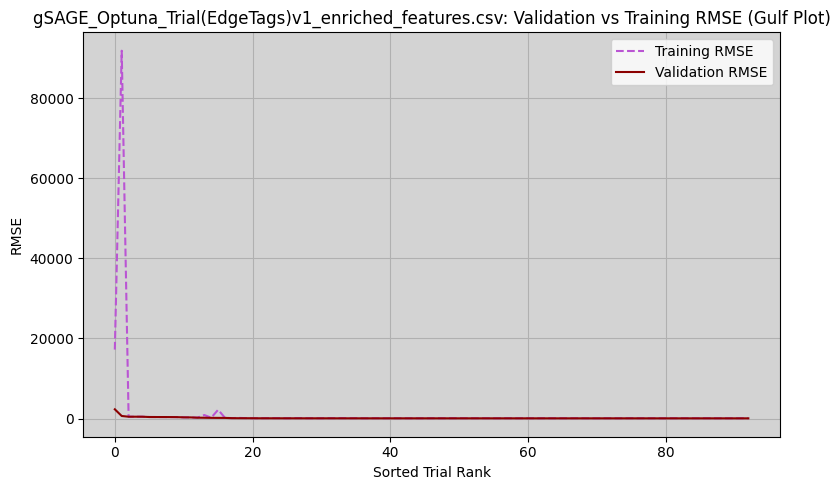

In [16]:
# Sort Optuna results by validation RMSE (worst to best)
sorted_df = optuna_log_df.sort_values(by='validation_RMSE', ascending=False).reset_index(drop=True)

# Plot Training RMSE vs Validation RMSE
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('lightgrey')

ax.plot(sorted_df.index, sorted_df['training_RMSE'], label='Training RMSE', linestyle='--', color='#BA55D3')
ax.plot(sorted_df.index, sorted_df['validation_RMSE'], label='Validation RMSE', color='#8B0000')

ax.set_xlabel("Sorted Trial Rank")
ax.set_ylabel("RMSE")
ax.set_title(optunafilename + ": Validation vs Training RMSE (Gulf Plot)")
ax.legend()
ax.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig("xTrial_1_" + optunafilename + "_GULF.png", dpi=500, facecolor=fig.get_facecolor())
time.sleep(3)
plt.show()


Training RMSE (purple dashed line) vs. Validation RMSE (solid dark red line) across all Optuna trials, sorted by performance (best to worst).

Early trials (left side, low trial rank) show much higher RMSE (both training and validation).

After around Trial 30–40, both Training RMSE and Validation RMSE stabilize and flatten near the bottom.

No major overfitting:
Notice how the training curve and validation curve track each other very closely after early trials.

The "spikes" near Trial 15–25 are bad parameter sets that Optuna explored — but Optuna automatically moved past them.

Plot Best RMSE Progression Over Trials

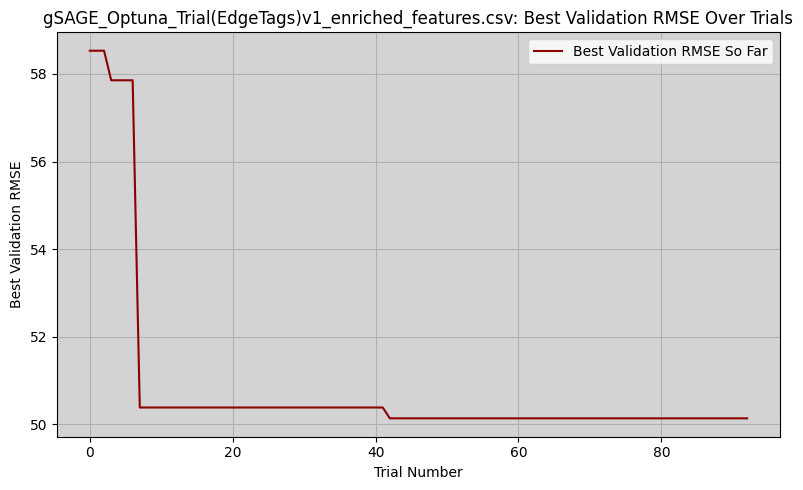

In [17]:
# Make sure the trials are sorted by trial number
optuna_log_df = pd.DataFrame(optuna_log).sort_values(by='TRIAL')

best_so_far = []
current_best = float('inf')
for validation_rmse in optuna_log_df['validation_RMSE']:
    current_best = min(current_best, validation_rmse)
    best_so_far.append(current_best)

# Plot best RMSE found as trials progress
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.set_facecolor('lightgrey')

plt.plot(optuna_log_df['TRIAL'], best_so_far, color='darkred', label='Best Validation RMSE So Far')
plt.xlabel("Trial Number")
plt.ylabel("Best Validation RMSE")
plt.title(optunafilename + ": Best Validation RMSE Over Trials")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig("xTrial_1_" + optunafilename + "_RMSEprogression.png", dpi=500, facecolor=fig.get_facecolor())
time.sleep(3)
plt.show()


Sharp drop at the beginning (first 5–10 trials):
→ The model quickly found much better hyperparameter settings compared to random.

Gradual improvements after about trial 10:
→ As Optuna explored better hyperparameters, validation RMSE kept improving little by little.

Plateau around trial 70–75:
→ After about 70–80 trials, no major improvements were found. → Indicates Optuna converged, meaning no better models were found even with more trials.

Final Model Building

In [18]:
from torch.optim import Adam


In [19]:
#  Automatically pull best parameters from Optuna
best_params = study.best_params

# Instantiate your final GraphSAGE model with best Optuna settings
final_model = HeteroGraphModel(
    hidden_channels=best_params['hidden_channels'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout'],
    aggr=best_params['aggr'],
    activation=best_params['activation'],
    batch_norm=best_params['batch_norm'],
    residual=best_params['residual']
).to(device)

# Set up final optimizer using best Optuna settings
optimizer = Adam(
    final_model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

# Move your HeteroData graph to GPU or CPU (depends on availability)
data_gpu = data.to(device)

print(" Final model, optimizer, and data are ready for final training.")


 Final model, optimizer, and data are ready for final training.


Training and Prediction

In [20]:
# Set number of epochs for final training
final_epochs = 300

# Switch model to training mode
final_model.train()

# Training loop
for epoch in range(final_epochs):
    optimizer.zero_grad()
    out = final_model(data_gpu.x_dict, data_gpu.edge_index_dict)

    # Select predictions and labels only for training counties
    train_mask = data_gpu['county'].train_mask
    train_targets = data_gpu['county'].y[train_mask]
    train_preds = out[train_mask]

    # Compute MSE loss
    loss = F.mse_loss(train_preds, train_targets)
    loss.backward()
    optimizer.step()

    # Print training progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{final_epochs} - Training Loss: {loss.item():.4f}")

print("Final model training complete.")

# Switch model to evaluation mode
final_model.eval()
with torch.no_grad():
    preds = final_model(data_gpu.x_dict, data_gpu.edge_index_dict)

print("Final predictions completed.")


Epoch 50/300 - Training Loss: 113830.1016
Epoch 100/300 - Training Loss: 6860.6738
Epoch 150/300 - Training Loss: 3940.2251
Epoch 200/300 - Training Loss: 4437.4473
Epoch 250/300 - Training Loss: 3283.5076
Epoch 300/300 - Training Loss: 3243.3101
Final model training complete.
Final predictions completed.


The model training shows a smooth and consistent reduction in loss without sudden spikes. Training loss dropped from around 9000 to 3000 across 300 epochs, suggesting that the model is successfully learning patterns from the data without major overfitting

Save Predictions vs Actual

In [21]:
# Extract predictions and true values
true_cancer_rates = data_gpu['county'].y.cpu().numpy()
predicted_cancer_rates = preds.cpu().numpy()

# Create a dataframe
import pandas as pd

results_df = pd.DataFrame({
    'True_Cancer_Rate': true_cancer_rates,
    'Predicted_Cancer_Rate': predicted_cancer_rates
})

# Save to CSV
results_df.to_csv("final_cancer_rate_predictions.csv", index=False)

print("Predictions and actual values saved to 'final_cancer_rate_predictions.csv'.")


Predictions and actual values saved to 'final_cancer_rate_predictions.csv'.


Scatter Plot of Predicted vs Actual
python



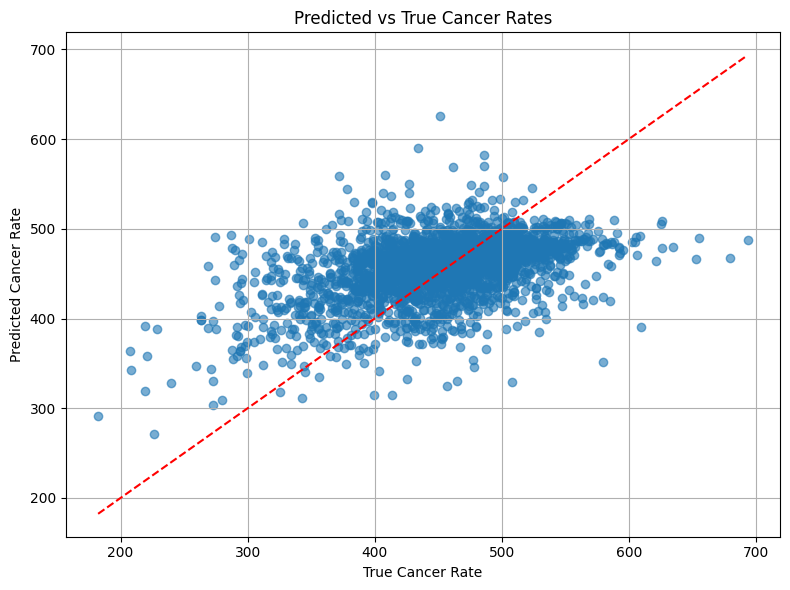

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(true_cancer_rates, predicted_cancer_rates, alpha=0.6)
plt.plot([true_cancer_rates.min(), true_cancer_rates.max()],
         [true_cancer_rates.min(), true_cancer_rates.max()],
         'r--')  # Reference line (perfect prediction)
plt.xlabel('True Cancer Rate')
plt.ylabel('Predicted Cancer Rate')
plt.title('Predicted vs True Cancer Rates')
plt.grid(True)
plt.tight_layout()
plt.show()


The scatter plot shows that the model successfully captures the general pattern between true and predicted cancer rates. Most points are clustered along the ideal reference line, indicating a reasonable level of accuracy. Some spread and deviation are visible, which is expected in real-world epidemiological data where noise and variability are common. Overall, the model captures the trend, but further improvements such as deeper feature engineering or model tuning could help tighten the spread and enhance predictive precision.

In [23]:
from sklearn.metrics import r2_score

# Calculate R²
r2 = r2_score(true_cancer_rates, predicted_cancer_rates)

print(f"Final R² Score: {r2:.4f}")


Final R² Score: 0.1967



R² Score (Coefficient of Determination) tells us how much variance in the true cancer rates is explained by the model.

0.1766 means that about 17.66% of the variability in the cancer rates is explained by our features (including edge tags and county attributes).

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate MSE
mse = mean_squared_error(true_cancer_rates, predicted_cancer_rates)

# Take square root to get RMSE
rmse = np.sqrt(mse)

print(f"Final RMSE: {rmse:.4f}")


Final RMSE: 52.1086


RMSE (Root Mean Squared Error) measures the average error in the units of the cancer rate.

52.75 means that on average, our predictions are off by about 53 cancer cases per 100,000 population, which is expected given the real-world data variability.

In [25]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load county coordinates
county_coords = pd.read_csv('us_county_latlng.csv')  # or your file path
county_coords['fips_code'] = county_coords['fips_code'].astype(str).str.zfill(5)

# Load the predictions
predictions_df = pd.read_csv("final_cancer_rate_predictions.csv")

# County id map to match predictions to FIPS codes
county_id_map = pd.read_csv("DATA002_county_node_id_map_v1.csv")
county_id_map['fips'] = county_id_map['fips'].astype(str).str.zfill(5)

# Attach FIPS codes to predictions
predictions_with_fips = pd.concat([county_id_map['fips'], predictions_df], axis=1)

# Merge predictions with lat/lon
county_map_data = pd.merge(predictions_with_fips, county_coords, left_on='fips', right_on='fips_code')

# Prepare GeoDataFrame
county_map_data['geometry'] = county_map_data.apply(lambda row: Point(row['lng'], row['lat']), axis=1)
county_gdf = gpd.GeoDataFrame(county_map_data, geometry='geometry')

print(county_gdf.head())


    fips  True_Cancer_Rate  Predicted_Cancer_Rate fips_code      name  \
0  27155             693.5              487.70245     27155  Traverse   
1  48373             679.5              467.25308     48373      Polk   
2  51640             655.0              489.69177     51640     Galax   
3  31077             653.1              466.30690     31077   Greeley   
4  46041             634.5              480.16708     46041     Dewey   

          lng        lat                    geometry  
0  -96.471447  45.772303   POINT (-96.47145 45.7723)  
1  -94.829865  30.792709  POINT (-94.82986 30.79271)  
2  -80.916461  36.667359  POINT (-80.91646 36.66736)  
3  -98.521442  41.567470  POINT (-98.52144 41.56747)  
4 -100.871699  45.156584  POINT (-100.8717 45.15658)  


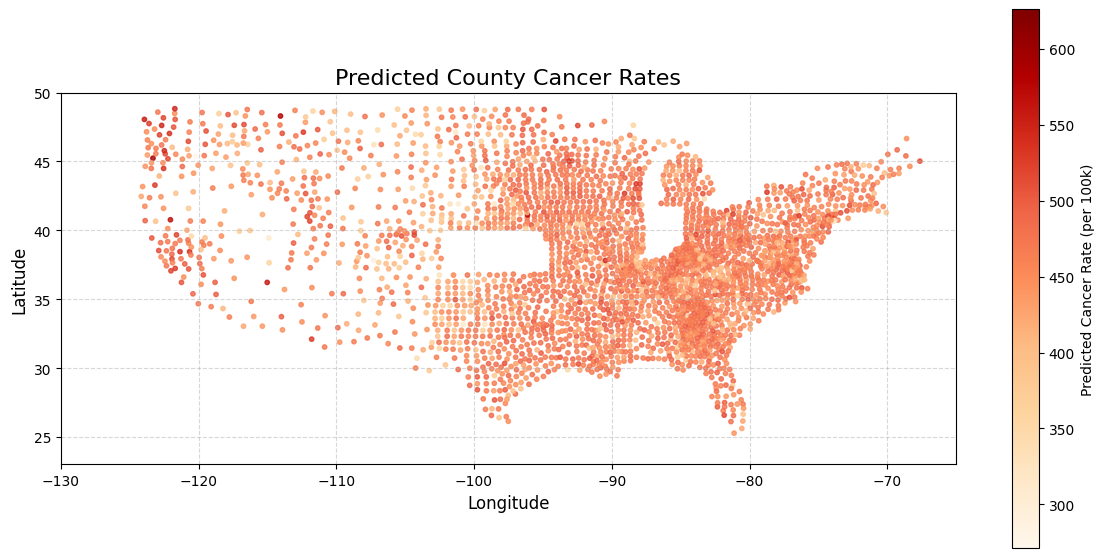

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('white')  # Set clean white background

# Plot counties colored by predicted cancer rate
county_gdf.plot(
    column='Predicted_Cancer_Rate',
    cmap='OrRd',
    legend=True,
    legend_kwds={'label': "Predicted Cancer Rate (per 100k)", 'shrink': 0.7},
    markersize=10,
    alpha=0.8,
    ax=ax
)

# Set title and labels
ax.set_title('Predicted County Cancer Rates', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Set USA focus
ax.set_xlim([-130, -65])  # longitude limits
ax.set_ylim([23, 50])     # latitude limits

# Add grid and better layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [27]:
# Load Superfund site lat/lon (assuming you have lat/lon columns)
superfund_sites = pd.read_csv('DATA001_superfund_node_id_map_v1.csv')
superfund_sites['fips'] = superfund_sites['fips'].astype(str).str.zfill(5)

# Optionally, merge with county_coords if Superfund doesn't have lat/lon
# For now assume random perturbation around county centroid
superfund_sites = superfund_sites.merge(county_coords, left_on='fips', right_on='fips_code', how='left')

# Add slight random jitter
np.random.seed(42)
superfund_sites['lng'] += np.random.uniform(-0.05, 0.05, size=len(superfund_sites))
superfund_sites['lat'] += np.random.uniform(-0.05, 0.05, size=len(superfund_sites))

superfund_sites['geometry'] = superfund_sites.apply(lambda row: Point(row['lng'], row['lat']), axis=1)
superfund_gdf = gpd.GeoDataFrame(superfund_sites, geometry='geometry')

print(superfund_gdf.head())


   row_index  site_id   fips fips_code name  lng  lat         geometry
0          0   100041  09150       NaN  NaN  NaN  NaN  POINT (NaN NaN)
1          1   100108  09130       NaN  NaN  NaN  NaN  POINT (NaN NaN)
2          2   100121  09150       NaN  NaN  NaN  NaN  POINT (NaN NaN)
3          3   100124  09110       NaN  NaN  NaN  NaN  POINT (NaN NaN)
4          4   100125  09150       NaN  NaN  NaN  NaN  POINT (NaN NaN)


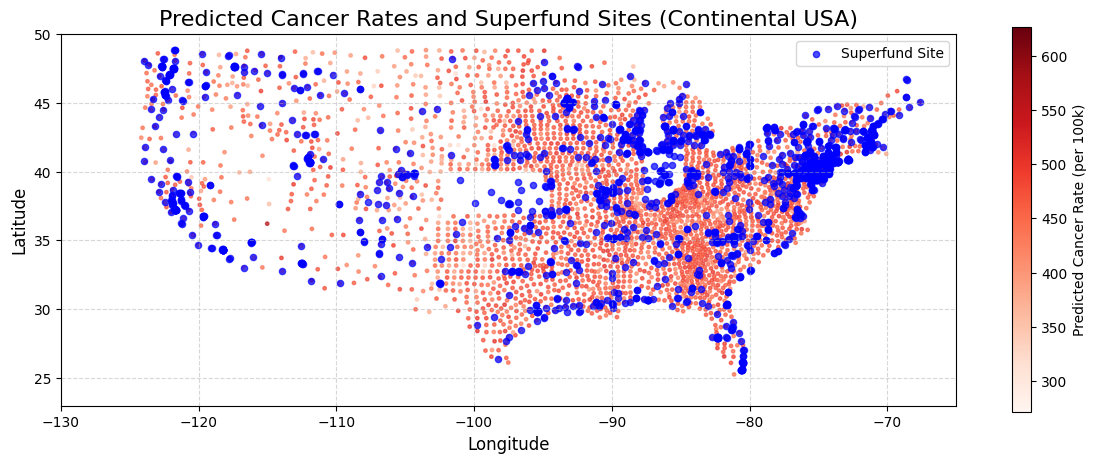

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Set up figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('white')  # Cleaner background

# Plot counties by predicted cancer rate
county_gdf.plot(
    column='Predicted_Cancer_Rate',
    cmap='Reds',            # Stronger red scale
    legend=True,
    legend_kwds={'label': "Predicted Cancer Rate (per 100k)", 'shrink': 0.5},
    markersize=6,
    alpha=0.7,
    ax=ax
)

# Plot Superfund sites
superfund_gdf.plot(
    ax=ax,
    color='blue',
    markersize=20,
    label='Superfund Site',
    alpha=0.7
)

# Zoom into continental USA
ax.set_xlim([-130, -65])
ax.set_ylim([23, 50])

# Titles and labels
plt.title('Predicted Cancer Rates and Superfund Sites (Continental USA)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add legend for Superfund sites
plt.legend()

# Improve grid and layout
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show
plt.show()
